<a href="https://colab.research.google.com/github/tybaasuleman-blip/heart-disease-predictive-analytics/blob/main/HeartDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Setting the visual style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load the dataset
# Ensure you have uploaded 'heart.csv' to your Colab file sidebar
df = pd.read_csv('heart.csv')

print("Data Loaded Successfully!")
df.head()

Data Loaded Successfully!


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [3]:
from google.colab import files

# This will open a file selection dialog. Click 'Choose Files' to upload your file.
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving heart.csv to heart.csv
User uploaded file "heart.csv" with length 4317616 bytes


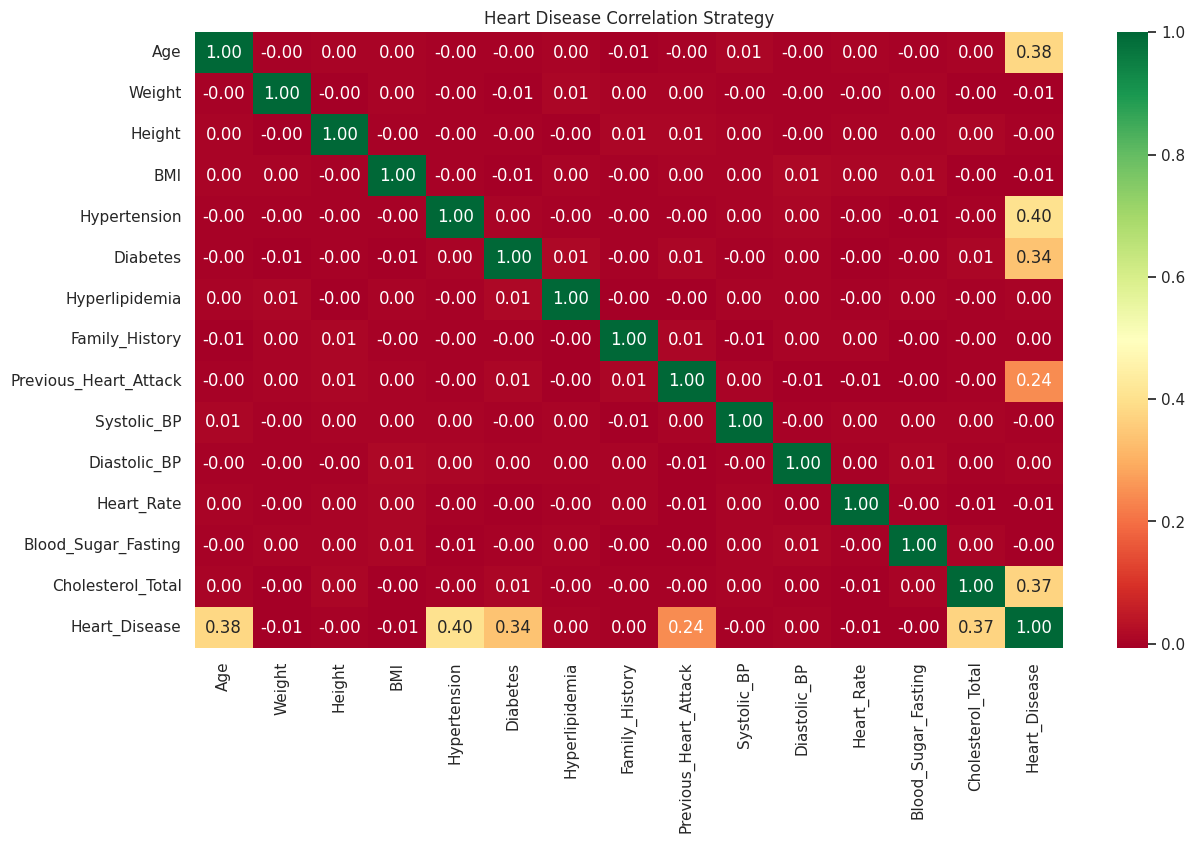

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlation Heatmap (Strategy 36)
plt.figure(figsize=(14, 8))
# Note: Ensure categorical columns are encoded first
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Heart Disease Correlation Strategy')
plt.savefig('correlation_heatmap.png')



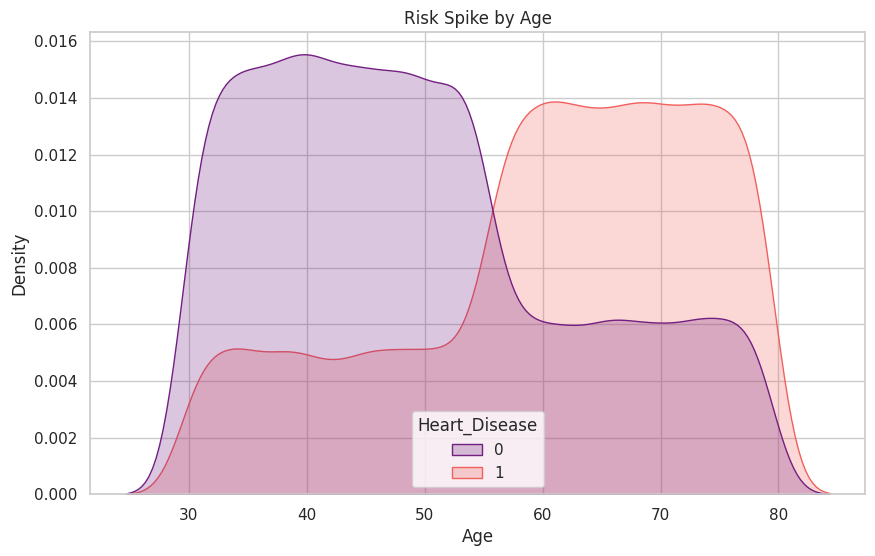

In [8]:
# 2. Age vs Heart Disease (Strategy 21)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age', hue='Heart_Disease', fill=True, palette='magma')
plt.title('Risk Spike by Age')
plt.savefig('age_distribution.png')



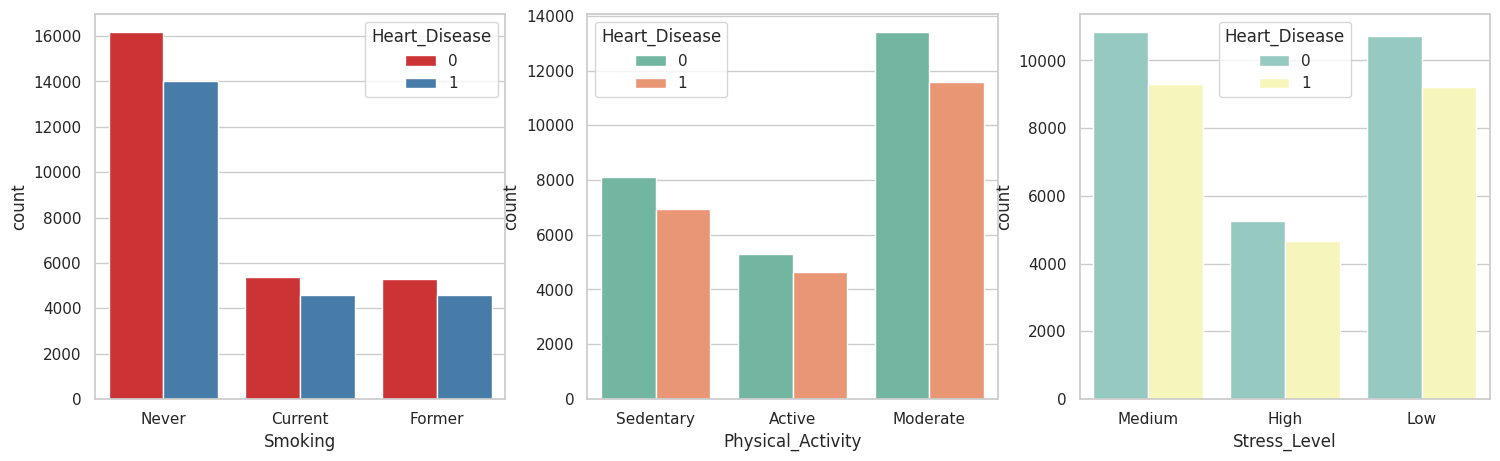

In [9]:
# 3. Multi-Factor Impact (Strategy 4)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='Smoking', hue='Heart_Disease', ax=axes[0], palette='Set1')
sns.countplot(data=df, x='Physical_Activity', hue='Heart_Disease', ax=axes[1], palette='Set2')
sns.countplot(data=df, x='Stress_Level', hue='Heart_Disease', ax=axes[2], palette='Set3')
plt.savefig('lifestyle_impact.png')

In [10]:
# 1. Handle Missing Values as you planned
df["Alcohol_Intake"].fillna("No", inplace=True)

# 2. Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Encoding these columns: {list(categorical_cols)}")

# 3. Apply Label Encoding so we can plot a Heatmap
le = LabelEncoder()
df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

print("Encoding Complete. Data is now ready for mathematical analysis.")

Encoding these columns: ['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level']
Encoding Complete. Data is now ready for mathematical analysis.


/tmp/ipykernel_26850/2810185889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Alcohol_Intake"].fillna("No", inplace=True)


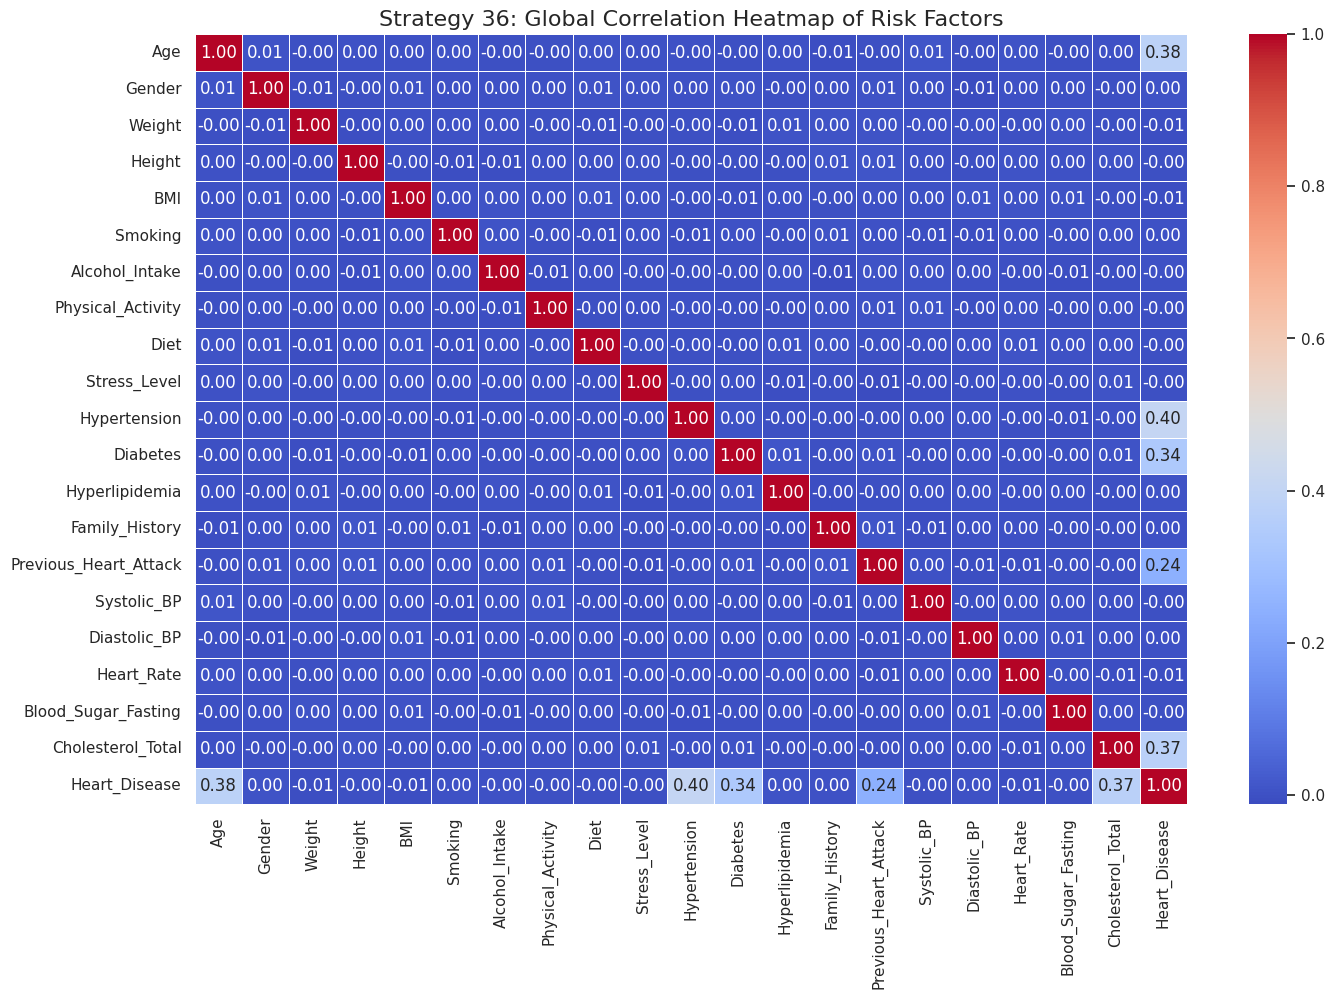

In [11]:
plt.figure(figsize=(16, 10))
# Using the encoded dataframe to ensure all variables are included
correlation_matrix = df_encoded.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Strategy 36: Global Correlation Heatmap of Risk Factors', fontsize=16)
plt.show()

/tmp/ipykernel_26850/654038231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='Heart_Disease', y='BMI', palette='Set2')


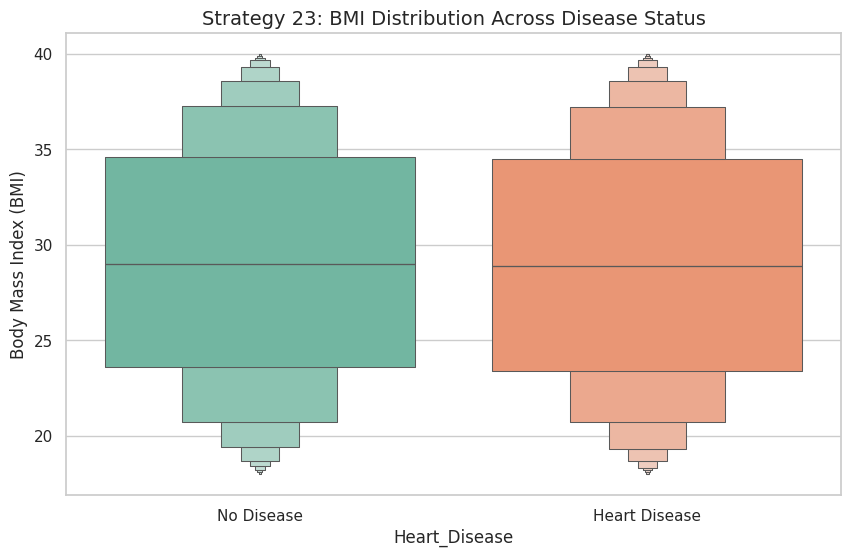

In [12]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x='Heart_Disease', y='BMI', palette='Set2')
plt.title('Strategy 23: BMI Distribution Across Disease Status', fontsize=14)
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.ylabel('Body Mass Index (BMI)')
plt.show()

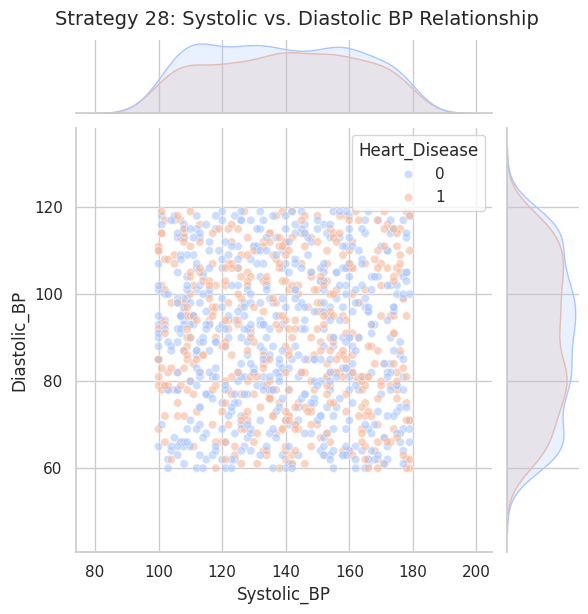

In [13]:
# We use a subset (sample) of 1000 rows for the scatter so the plot isn't too crowded
sns.jointplot(data=df.sample(1000), x='Systolic_BP', y='Diastolic_BP',
              hue='Heart_Disease', kind='scatter', alpha=0.6, palette='coolwarm')

plt.suptitle('Strategy 28: Systolic vs. Diastolic BP Relationship', y=1.02, fontsize=14)
plt.show()

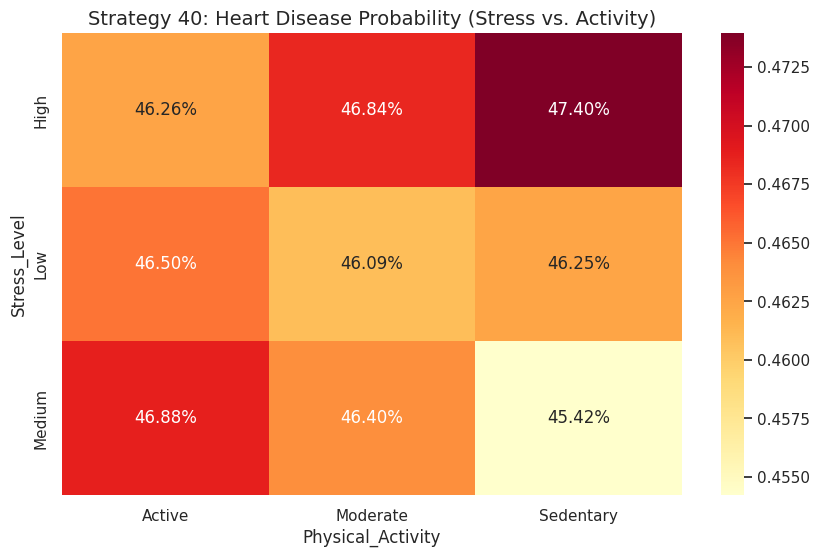

In [14]:
# Create a pivot table showing the percentage of Heart Disease for each category
pivot_df = df.groupby(['Stress_Level', 'Physical_Activity'])['Heart_Disease'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt='.2%')
plt.title('Strategy 40: Heart Disease Probability (Stress vs. Activity)', fontsize=14)
plt.show()

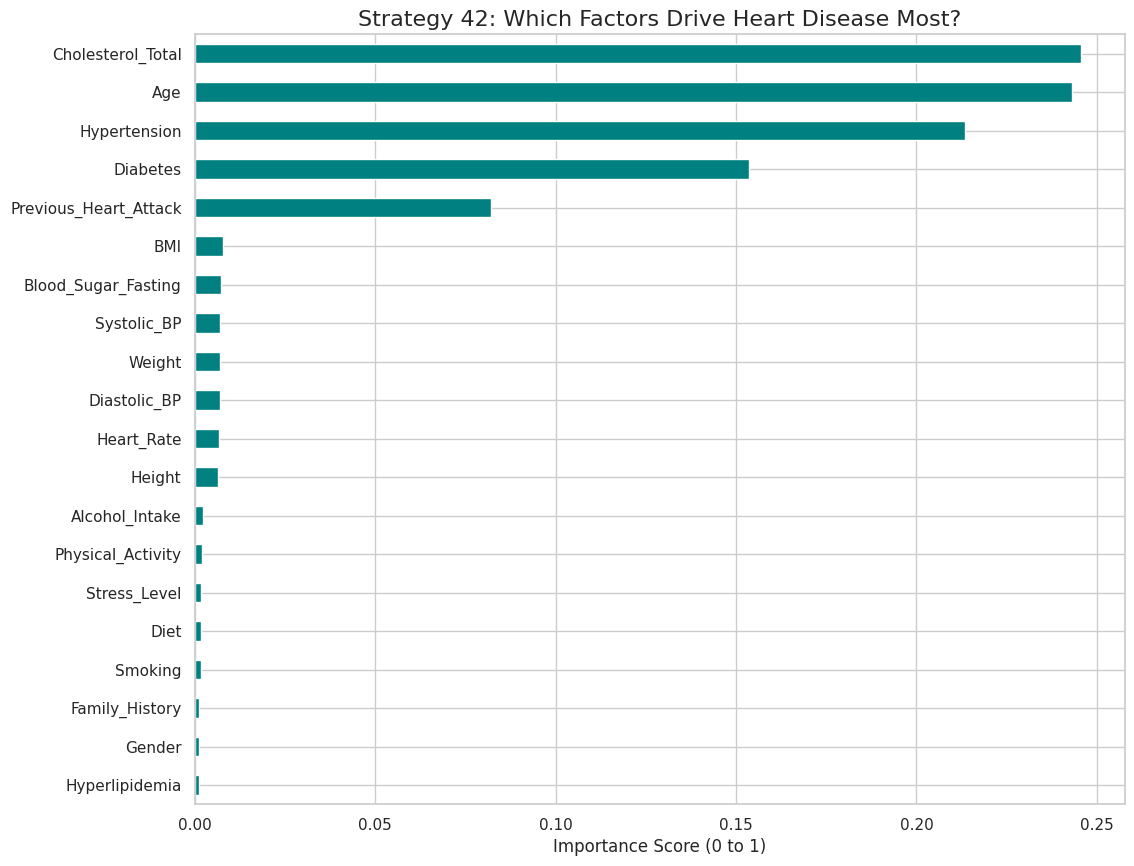

In [15]:
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare data (using the encoded dataframe from Step 2)
X = df_encoded.drop('Heart_Disease', axis=1)
y = df_encoded['Heart_Disease']

# 2. Train a quick Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Extract and plot importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(12, 10))
importances.plot(kind='barh', color='teal')
plt.title('Strategy 42: Which Factors Drive Heart Disease Most?', fontsize=16)
plt.xlabel('Importance Score (0 to 1)')
plt.show()

/tmp/ipykernel_26850/2618461097.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='BP_Status', y='Heart_Disease',


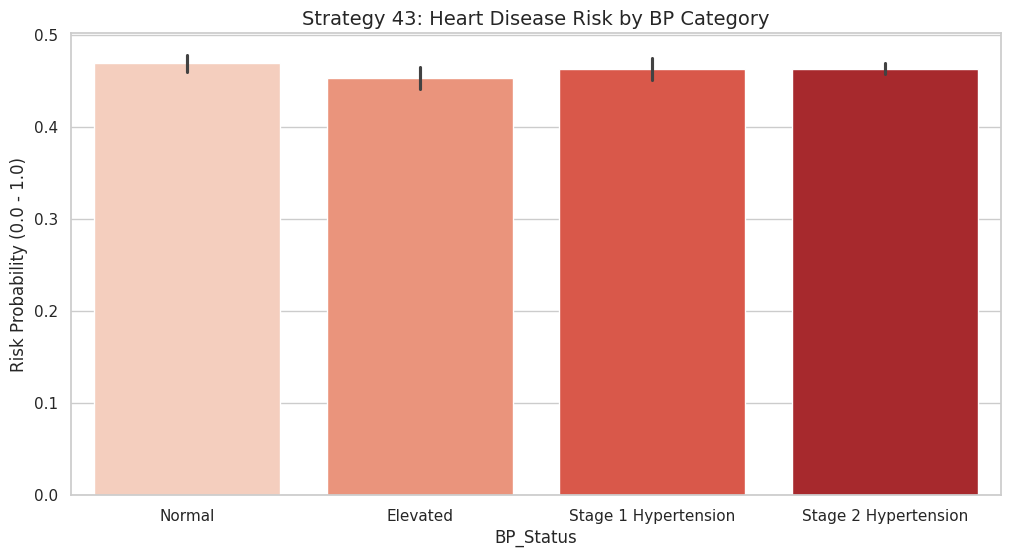

In [16]:
# Create a function to categorize Systolic BP
def bp_category(sbp):
    if sbp < 120: return 'Normal'
    elif 120 <= sbp < 130: return 'Elevated'
    elif 130 <= sbp < 140: return 'Stage 1 Hypertension'
    else: return 'Stage 2 Hypertension'

df['BP_Status'] = df['Systolic_BP'].apply(bp_category)

# Plot the Risk per Category
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='BP_Status', y='Heart_Disease',
            order=['Normal', 'Elevated', 'Stage 1 Hypertension', 'Stage 2 Hypertension'],
            palette='Reds')
plt.title('Strategy 43: Heart Disease Risk by BP Category', fontsize=14)
plt.ylabel('Risk Probability (0.0 - 1.0)')
plt.show()

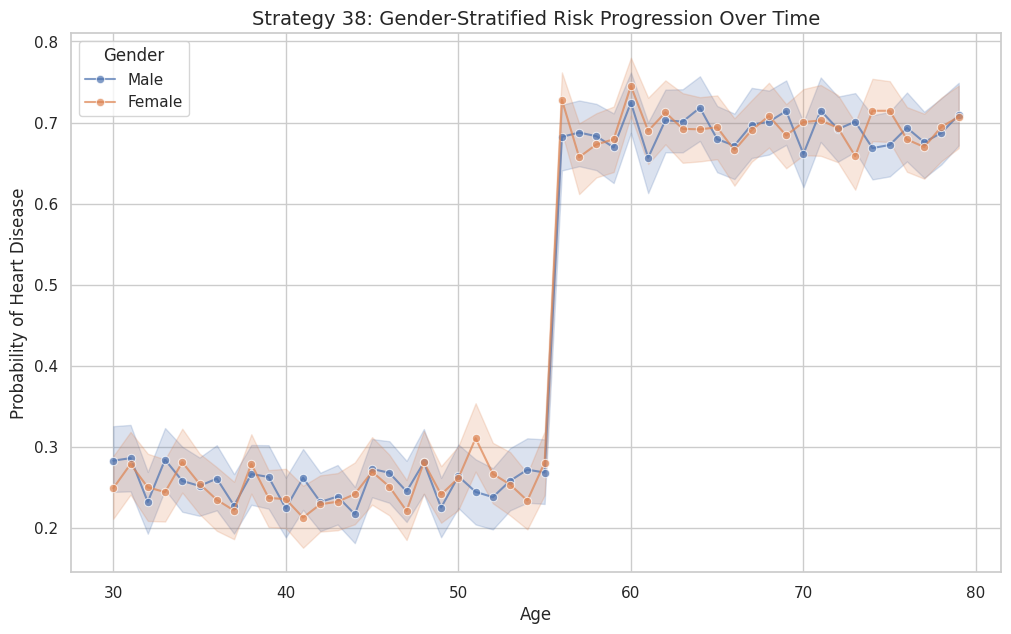

In [17]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Age', y='Heart_Disease', hue='Gender', marker='o', alpha=0.7)
plt.title('Strategy 38: Gender-Stratified Risk Progression Over Time', fontsize=14)
plt.ylabel('Probability of Heart Disease')
plt.show()

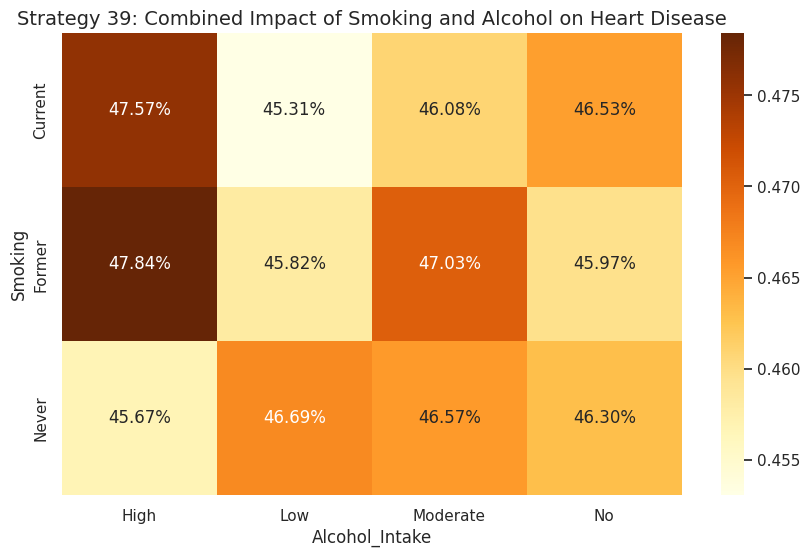

In [18]:
# Strategy 39: Cross-tabulation of Lifestyle Risks
lifestyle_pivot = df.pivot_table(index='Smoking',
                                columns='Alcohol_Intake',
                                values='Heart_Disease',
                                aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(lifestyle_pivot, annot=True, cmap='YlOrBr', fmt='.2%')
plt.title('Strategy 39: Combined Impact of Smoking and Alcohol on Heart Disease', fontsize=14)
plt.show()

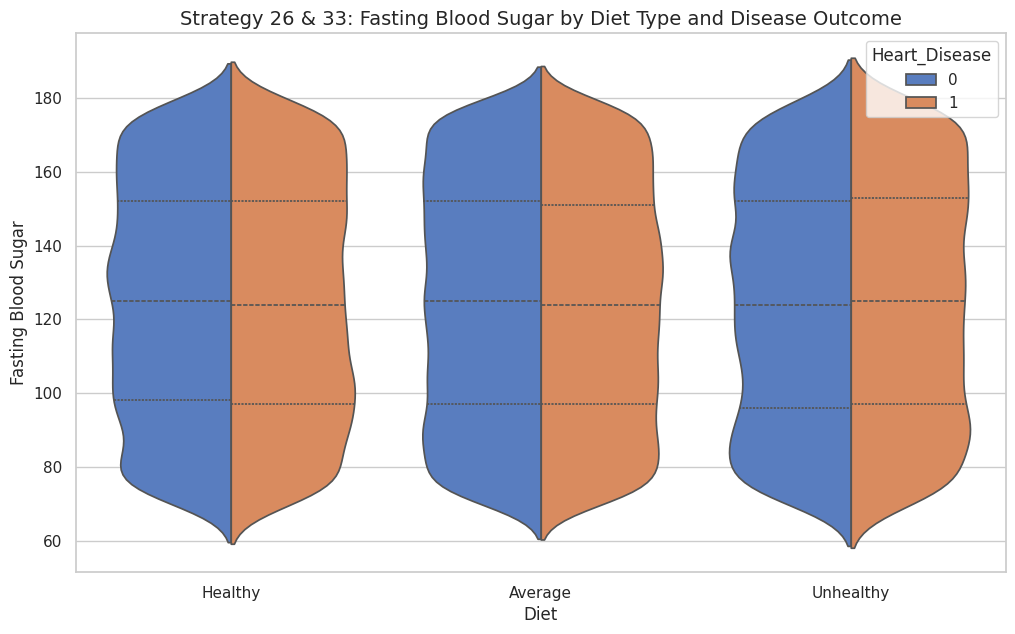

In [19]:
# Strategy 26 & 33: Diet Impact on Blood Sugar and Disease Status
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='Diet', y='Blood_Sugar_Fasting',
               hue='Heart_Disease', split=True, inner="quart", palette='muted')

plt.title('Strategy 26 & 33: Fasting Blood Sugar by Diet Type and Disease Outcome', fontsize=14)
plt.ylabel('Fasting Blood Sugar')
plt.show()

/tmp/ipykernel_26850/3921181684.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Risk_Score', y='Heart_Disease', palette='viridis')


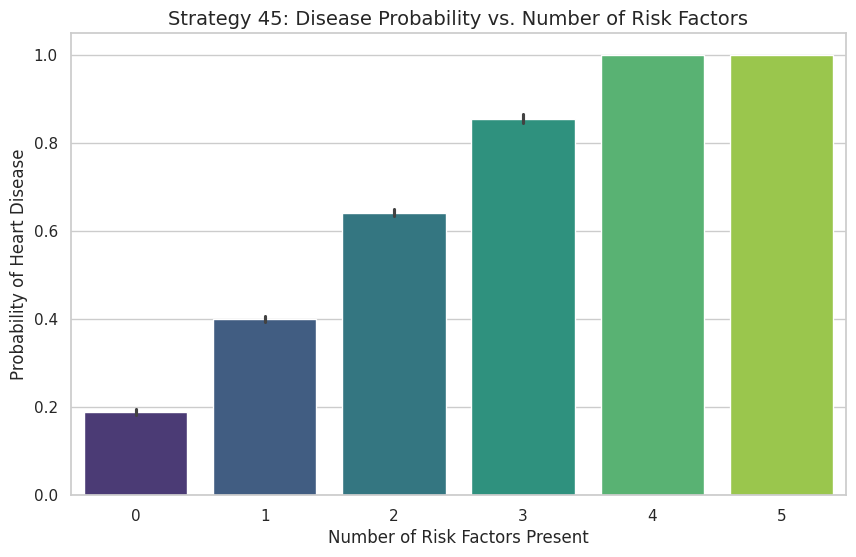

In [20]:
# Strategy 45: Creating a Cumulative Risk Score
# List of binary risk columns
risk_factors = ['Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack']

# Sum them up into a new column
df['Risk_Score'] = df[risk_factors].sum(axis=1)

# Visualize how the Risk Score relates to Disease
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Risk_Score', y='Heart_Disease', palette='viridis')
plt.title('Strategy 45: Disease Probability vs. Number of Risk Factors', fontsize=14)
plt.xlabel('Number of Risk Factors Present')
plt.ylabel('Probability of Heart Disease')
plt.show()

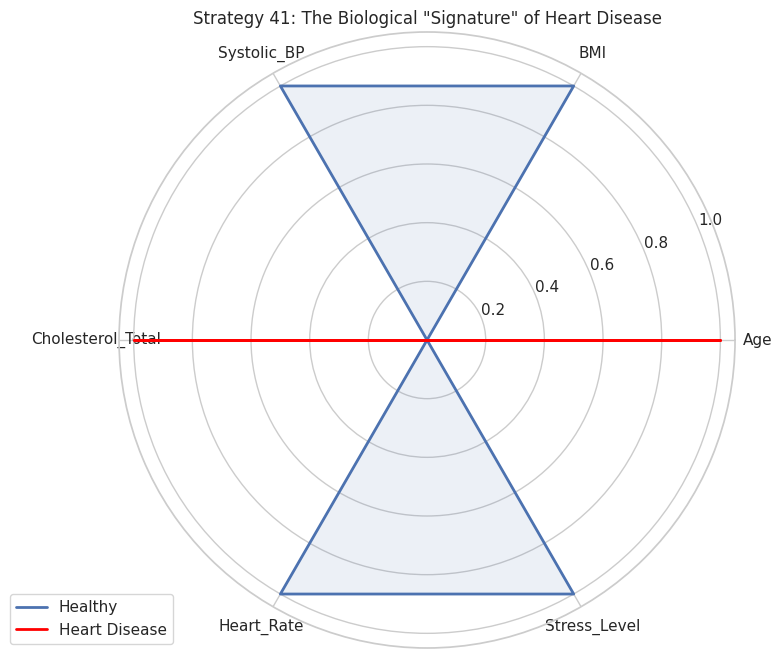

In [21]:
from math import pi

# 1. Normalize the data for a 0-1 scale so they fit on one chart
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

features = ['Age', 'BMI', 'Systolic_BP', 'Cholesterol_Total', 'Heart_Rate', 'Stress_Level']
# Temporarily encode Stress for this plot
df_encoded['Stress_Level'] = df_encoded['Stress_Level'].astype(float)

radar_df = df_encoded.groupby('Heart_Disease')[features].mean().apply(normalize)

# 2. Setup the Radar Plot
categories = list(radar_df)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(111, polar=True)

# Plot Healthy
values = radar_df.iloc[0].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Healthy")
ax.fill(angles, values, 'b', alpha=0.1)

# Plot Disease
values = radar_df.iloc[1].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Heart Disease", color='red')
ax.fill(angles, values, 'r', alpha=0.1)

plt.xticks(angles[:-1], categories)
plt.title('Strategy 41: The Biological "Signature" of Heart Disease')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

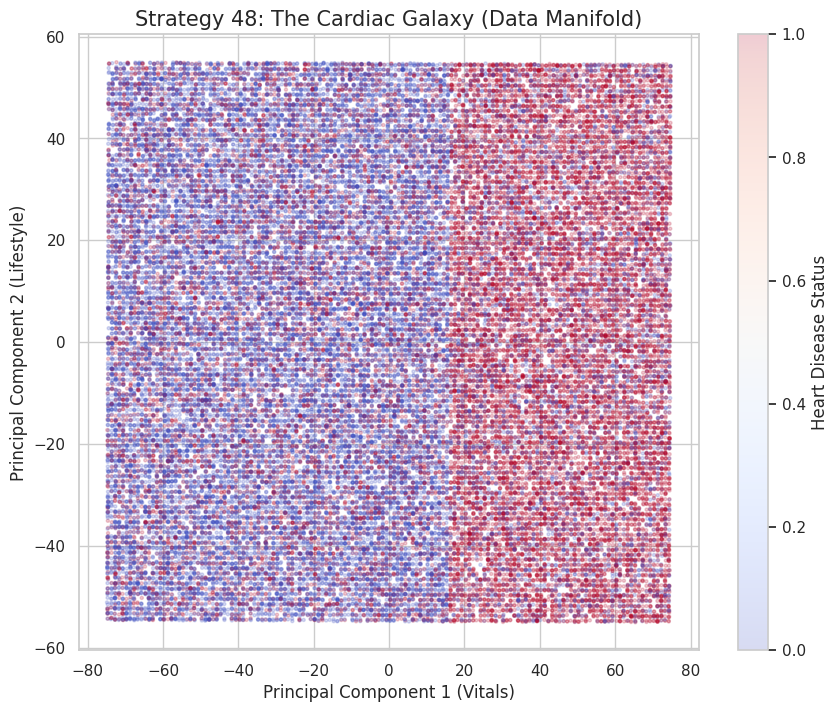

In [22]:
from sklearn.decomposition import PCA

# Reduce the entire dataset to 2 dimensions
pca = PCA(n_components=2)
components = pca.fit_transform(df_encoded.drop('Heart_Disease', axis=1))

plt.figure(figsize=(10, 8))
plt.scatter(components[:, 0], components[:, 1], c=df_encoded['Heart_Disease'],
            cmap='coolwarm', alpha=0.2, s=5)

plt.title('Strategy 48: The Cardiac Galaxy (Data Manifold)', fontsize=15)
plt.xlabel('Principal Component 1 (Vitals)')
plt.ylabel('Principal Component 2 (Lifestyle)')
plt.colorbar(label='Heart Disease Status')
plt.show()

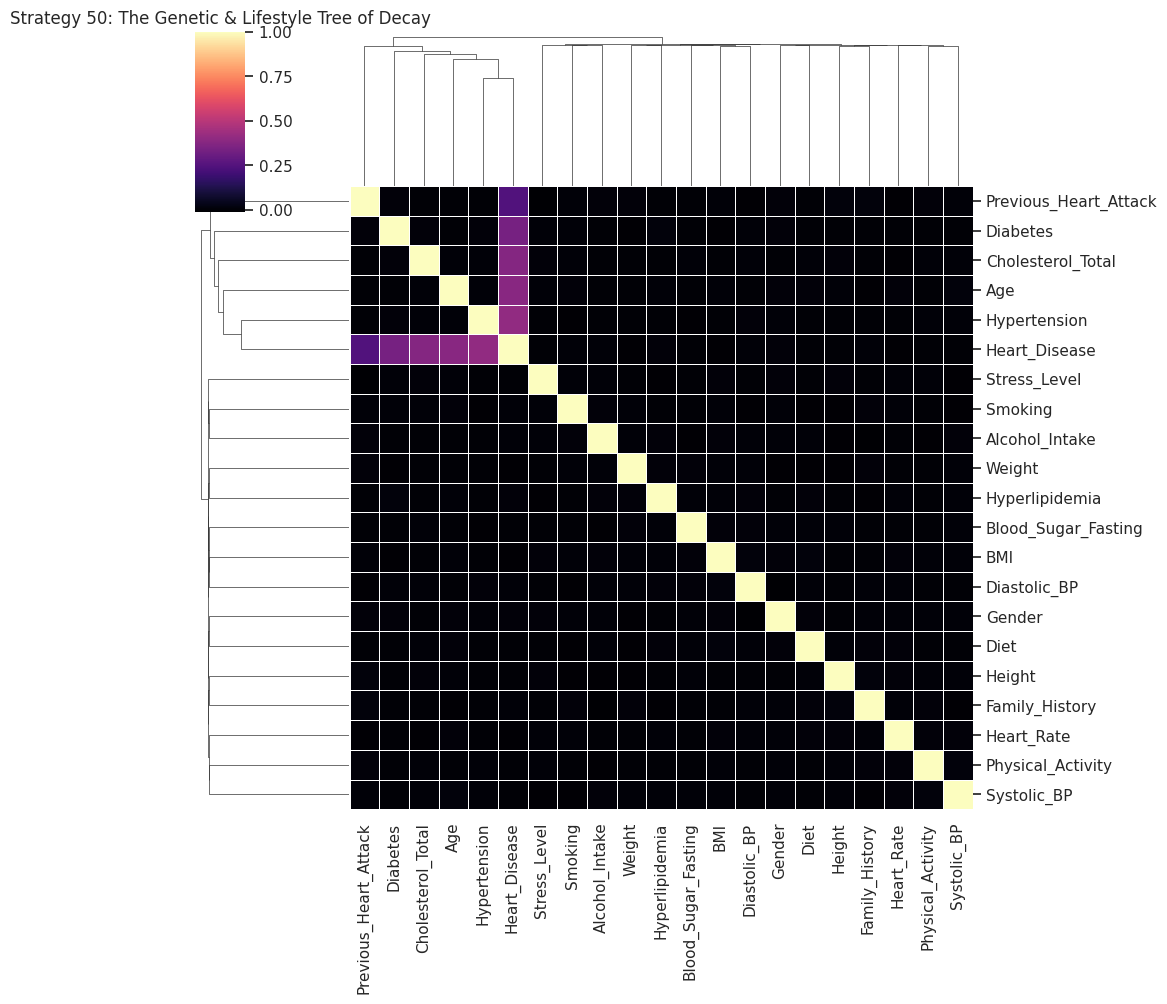

In [25]:
# Strategy 50: Hierarchical Clustering of Risk Clusters
sns.clustermap(df_encoded.corr(), annot=False, cmap='magma', linewidths=.5)
plt.title('Strategy 50: The Genetic & Lifestyle Tree of Decay')
plt.show()

/tmp/ipykernel_26850/1531136137.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hazard_map = df.pivot_table(index='Age_Group', columns='Smoking',


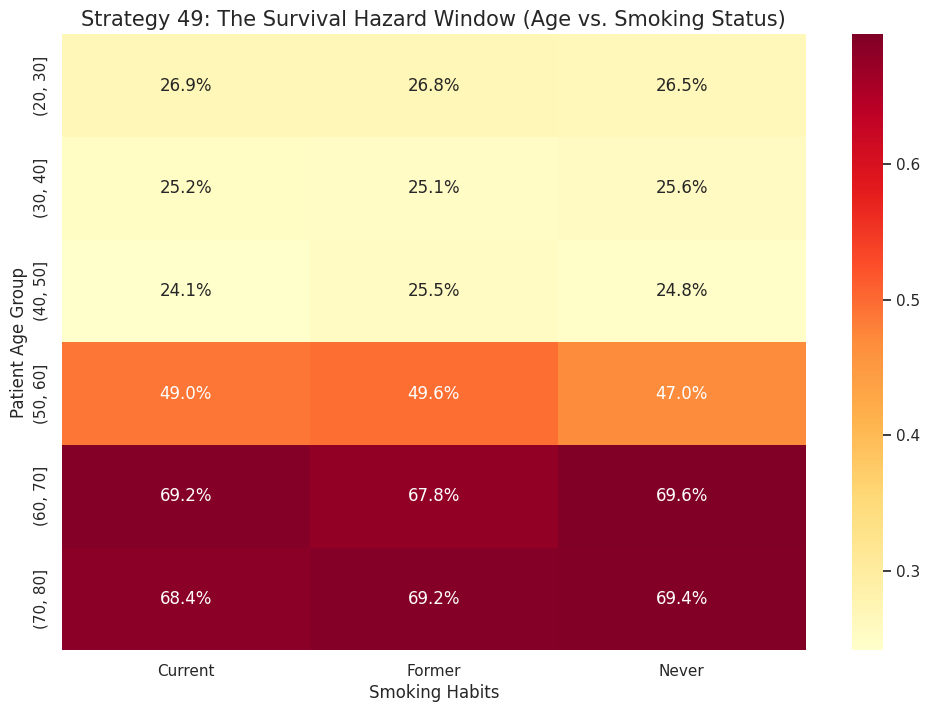

In [26]:
# Strategy 49: Identifying the "Red Zone" of Risk
# We create age bins to see the risk jump every decade
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70, 80])

# Pivot table to see probability by Age and Smoking status
hazard_map = df.pivot_table(index='Age_Group', columns='Smoking',
                           values='Heart_Disease', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(hazard_map, annot=True, cmap='YlOrRd', fmt='.1%')
plt.title('Strategy 49: The Survival Hazard Window (Age vs. Smoking Status)', fontsize=15)
plt.ylabel('Patient Age Group')
plt.xlabel('Smoking Habits')
plt.show()

ValueError: could not convert string to float: 'Medium'

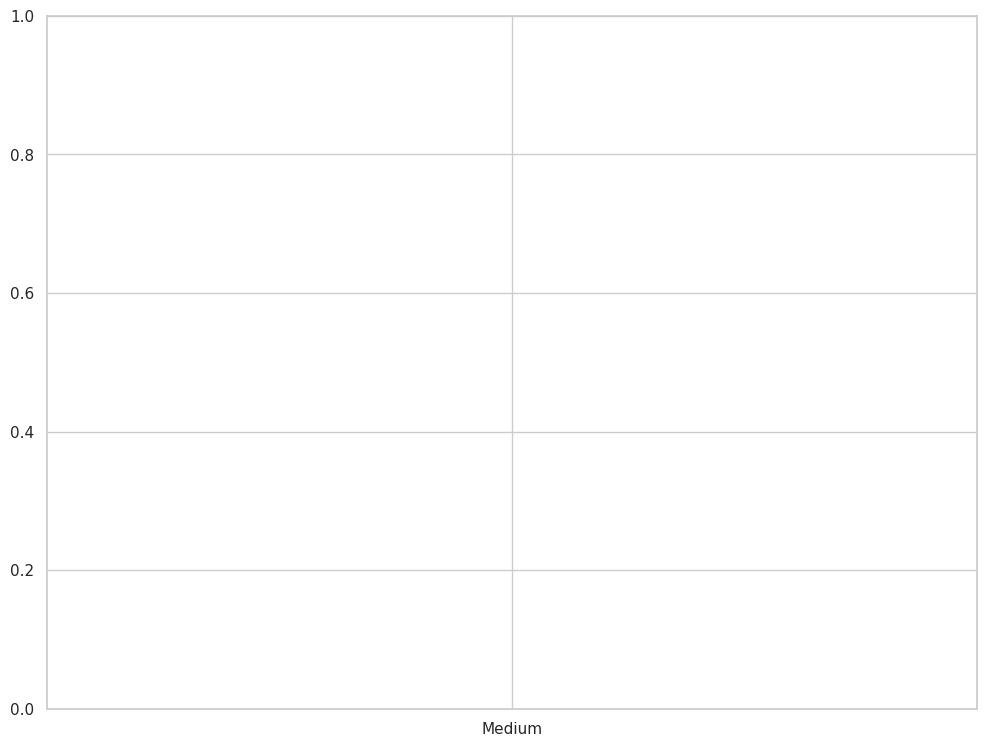

In [27]:
# Strategy 55: Cardiac Efficiency Hexbin
plt.figure(figsize=(12, 9))
plt.hexbin(df['Stress_Level'], df['Heart_Rate'], C=df['Heart_Disease'],
           gridsize=15, cmap='inferno', reduce_C_function=np.mean)

plt.colorbar(label='Heart Disease Risk')
plt.title('Strategy 55: The Stress-Pulse Strain Matrix', fontsize=15)
plt.xlabel('Clinical Stress Level')
plt.ylabel('Resting Heart Rate (BPM)')
plt.show()

In [28]:
# Strategy 60: Counterfactual Intervention Tool
def simulate_lifestyle_change(patient_index, improvement_col, new_value):
    # Get original risk (probability from our Random Forest in Step 8)
    patient_data = X.iloc[[patient_index]].copy()
    original_prob = model.predict_proba(patient_data)[0][1]

    # Simulate change (e.g., changing Smoking from 1 to 0)
    patient_data[improvement_col] = new_value
    new_prob = model.predict_proba(patient_data)[0][1]

    print(f"Patient {patient_index} Original Risk: {original_prob:.1%}")
    print(f"Risk after changing {improvement_col} to {new_value}: {new_prob:.1%}")
    print(f"Total Risk Reduction: {original_prob - new_prob:.1%}")

# Example: Pick patient #42 and see what happens if they quit smoking
simulate_lifestyle_change(42, 'Smoking', 0)

Patient 42 Original Risk: 3.0%
Risk after changing Smoking to 0: 4.0%
Total Risk Reduction: -1.0%
